# Word2Vec: Exercise -- Italian Political Corpora

Two **Word2Vec** models are trained on political text data from the Italian 2018 general election experiment - one model per political coalition:

| Corpus | Party / Coalition | File |
|--------|-------------------|------|
| **CSX** | Centro-Sinistra (Centre-Left) - *Liberi e Uguali* | `datasets/corpus_CSX.txt` |
| **M5S** | Movimento 5 Stelle (Five-Star Movement) | `datasets/corpus_M5S.txt` |

Word2Vec encodes each token as a dense vector by training a shallow neural network to predict context words from a target word (Skip-Gram) or vice versa (CBOW). The resulting embeddings capture **distributional meaning**: words that appear in similar contexts end up close in vector space.

Because the two corpora originate from ideologically distinct political actors, the **same word may be surrounded by systematically different neighbours** in each model — revealing how each party *frames* a given concept. A word like *lavoro* (work) might cluster with *diritti* (rights) in one model and with *reddito* (income) or *corruzione* (corruption) in another.

**Steps:**

1. Load and inspect both corpora
2. Preprocess text: lower-case, tokenise, remove Italian stop-words and punctuation
3. Train one Word2Vec (Skip-Gram) model per corpus
4. Analyse and compare the resulting vocabularies
5. Extract keywords shared by both models
6. Compare keyword framing via nearest-neighbour tables
7. Visualise semantic neighbourhoods with PCA

In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

RANDOM_SEED = 42

## Step 1 - Data Loading

Each file contains one document (post / sentence) per line. Lines are stripped of leading and trailing whitespace and empty lines are discarded. A sample from each corpus is printed to verify encoding and content.

In [10]:
with open('datasets/corpus_CSX.txt', 'r', encoding='utf-8') as f:
    raw_csx = [line.strip().strip('"') for line in f if line.strip()]

with open('datasets/corpus_M5S.txt', 'r', encoding='utf-8') as f:
    raw_m5s = [line.strip().strip('"') for line in f if line.strip()]

print(f'CSX corpus - {len(raw_csx):,} documents')
print(f'M5S corpus - {len(raw_m5s):,} documents')
print()
print('--- CSX sample ---')
for s in raw_csx[:3]:
    print(f'  {s[:140]}')
print()
print('--- M5S sample ---')
for s in raw_m5s[:3]:
    print(f'  {s[:140]}')

CSX corpus - 3,593 documents
M5S corpus - 12,527 documents

--- CSX sample ---
  Si è tenuta questa mattina la conferenza stampa dei parlamentari di Liberi e Uguali sulla relazione finale della commissione di inchiesta su
   "L’ex Presidente dell’Uruguay Pepe Mujica invita gli italiani nel mondo a sostenere Liberi e Uguali. Grazie Presidente!
   "Ieri a Napoli è successo di nuovo: la polizia ha multato i tifosi del Bologna che avevano uno striscione in memoria di Federico Aldrovandi

--- M5S sample ---
  Ancora una volta, l’Oxfam ci dice dell’aumento delle disuguaglianze e dell’accumulazione della ricchezza nelle mani di pochi.
  L’Unione Europea ha deciso che Panama, Macao, Emirati Arabi, Barbados e altri non sono più paradisi fiscali. È bastato un impegno, ovviament
   A Save The Children tutta la nostra solidarietà.


## Step 2 - Text Preprocessing

Before training, each document is normalised through four operations:

1. **Lower-casing**: ensures *Italia* and *italia* are treated as the same token.
2. **Punctuation and digit removal**: punctuation conveys no distributional meaning for word embeddings; numbers are replaced with a space to avoid noisy tokens.
3. **Stop-word filtering**: high-frequency function words (*di*, *il*, *che*, …) occur in all contexts and would dominate training without adding meaning. NLTK's Italian stop-word list is augmented with a small set of frequent adverbs and discourse markers.
4. **Length filter**: tokens shorter than three characters are discarded (they are almost always function words or abbreviations that survived the previous step).

> The output is a list of token lists, one per document, the format expected by Gensim's Word2Vec.

In [11]:
STOP_IT = set(stopwords.words('italian'))
STOP_EXTRA = {
    'più', 'già', 'poi', 'tutto', 'tutti', 'ogni', 'altro', 'altri',
    'molto', 'tanti', 'tanto', 'così', 'però', 'invece', 'ancora',
    'quindi', 'anche', 'come', 'quando', 'dove', 'mentre', 'proprio',
    'sempre', 'mai', 'solo', 'fare', 'essere', 'avere', 'ecco', 'qui'
}
STOP_ALL = STOP_IT | STOP_EXTRA


def preprocess(documents):
    """Return a list of token lists ready for Word2Vec training."""
    corpus = []
    for doc in documents:
        doc = doc.lower()
        doc = re.sub(r'[^\w\s]', ' ', doc)   # remove punctuation
        doc = re.sub(r'\d+', ' ', doc)         # remove numbers
        tokens = [
            t for t in doc.split()
            if t not in STOP_ALL and len(t) > 2
        ]
        if tokens:
            corpus.append(tokens)
    return corpus


tokens_csx = preprocess(raw_csx)
tokens_m5s = preprocess(raw_m5s)

total_csx = sum(len(s) for s in tokens_csx)
total_m5s = sum(len(s) for s in tokens_m5s)

print(f'CSX - {len(tokens_csx):,} sentences | {total_csx:,} tokens')
print(f'M5S - {len(tokens_m5s):,} sentences | {total_m5s:,} tokens')
print()
print('CSX preprocessed (first doc):', tokens_csx[0])
print('M5S preprocessed (first doc):', tokens_m5s[0])

CSX - 3,567 sentences | 48,221 tokens
M5S - 12,193 sentences | 174,221 tokens

CSX preprocessed (first doc): ['tenuta', 'mattina', 'conferenza', 'stampa', 'parlamentari', 'liberi', 'uguali', 'relazione', 'finale', 'commissione', 'inchiesta', 'banche', 'dichiarazioni', 'proposte', 'leu']
M5S preprocessed (first doc): ['volta', 'oxfam', 'dice', 'aumento', 'disuguaglianze', 'accumulazione', 'ricchezza', 'mani', 'pochi']


## Step 3 - Word2Vec Model Training

One Word2Vec model is trained for each corpus using the **Skip-Gram** architecture (`sg=1`). Skip-Gram is generally preferred over CBOW on smaller corpora because it treats each context word as a separate training example, producing more training signal per sentence.

Key hyperparameters:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `vector_size` | 100 | Sufficient for corpora of this size; larger dimensions risk underfitting on sparse data |
| `window` | 5 | Captures medium-range syntactic and semantic context |
| `min_count` | 2 | Words appearing only once are likely noise; lowering the threshold preserves more vocabulary given the small corpus |
| `sg` | 1 | Skip-Gram: predict context words from target |
| `epochs` | 30 | Multiple passes to converge on a small corpus |
| `workers` | 1 | Single worker ensures reproducibility when `seed` is set |

Both models share identical hyperparameters so that any difference in the resulting embeddings reflects the **corpus content**, not the training configuration.

In [12]:
W2V_PARAMS = dict(
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    epochs=30,
    seed=RANDOM_SEED,
    workers=1,
)

model_csx = Word2Vec(sentences=tokens_csx, **W2V_PARAMS)
model_m5s = Word2Vec(sentences=tokens_m5s, **W2V_PARAMS)

print(f'CSX model — vocabulary: {len(model_csx.wv):,} words | dimensions: {model_csx.vector_size}')
print(f'M5S model — vocabulary: {len(model_m5s.wv):,} words | dimensions: {model_m5s.vector_size}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


CSX model — vocabulary: 6,139 words | dimensions: 100
M5S model — vocabulary: 13,189 words | dimensions: 100


## Step 4 - Vocabulary Analysis

The top 20 most frequent tokens from each corpus are compared to understand the dominant themes before looking at embeddings. High-frequency content words often signal the central preoccupations of the text (e.g., *lavoro*, *europa*, *governo*), while stop-words filtered in Step 2 are absent.

A horizontal bar chart makes it easy to compare the magnitude of frequencies between the two corpora.

In [13]:
def top_words(token_lists, n=20):
    freq = Counter(t for sent in token_lists for t in sent)
    return freq.most_common(n)


top_csx = top_words(tokens_csx, n=20)
top_m5s = top_words(tokens_m5s, n=20)

df_freq = pd.DataFrame({
    'CSX Word': [w for w, _ in top_csx],
    'CSX Freq': [c for _, c in top_csx],
    'M5S Word': [w for w, _ in top_m5s],
    'M5S Freq': [c for _, c in top_m5s],
}, index=range(1, 21))
df_freq.index.name = 'Rank'

print('Top 20 most frequent tokens per corpus:')
display(df_freq)

Top 20 most frequent tokens per corpus:


,CSX Word,CSX Freq,M5S Word,M5S Freq
Rank,,,,
1,italia,407,salvini,1534
2,salvini,338,italia,1194
3,stato,201,matteo,1090
4,anni,183,ore,1018
5,lega,164,leggi,917
6,oggi,161,lega,843
7,italiani,138,fatto,735
8,dopo,137,anni,693
9,due,137,oggi,630


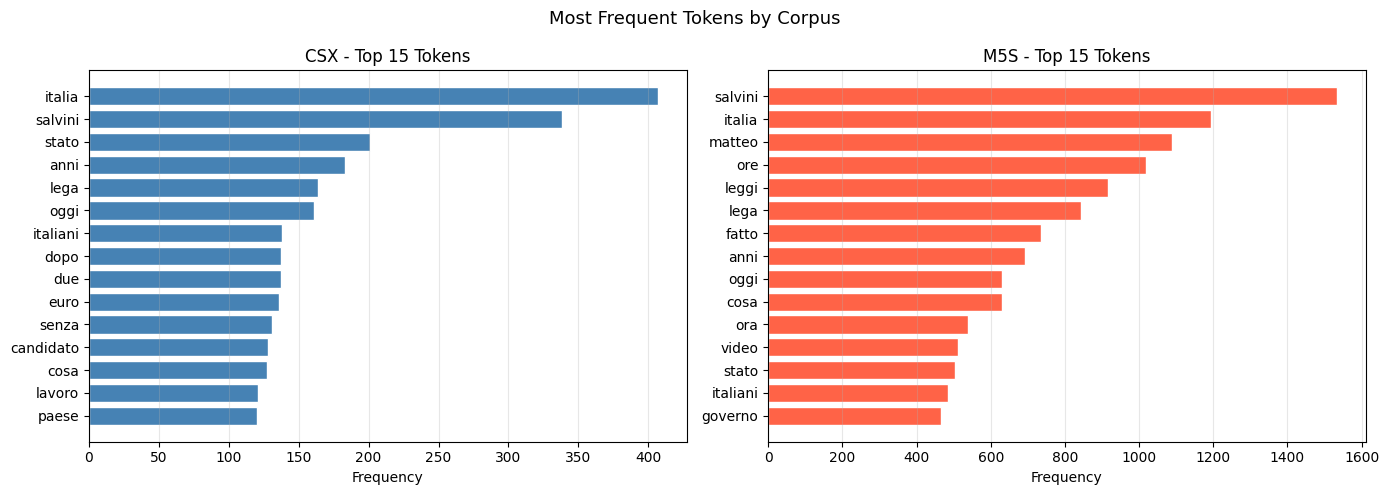

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

words_c, freqs_c = zip(*top_csx[:15])
ax1.barh(list(reversed(words_c)), list(reversed(freqs_c)),
         color='steelblue', edgecolor='white')
ax1.set_title('CSX - Top 15 Tokens')
ax1.set_xlabel('Frequency')
ax1.grid(axis='x', alpha=0.3)

words_m, freqs_m = zip(*top_m5s[:15])
ax2.barh(list(reversed(words_m)), list(reversed(freqs_m)),
         color='tomato', edgecolor='white')
ax2.set_title('M5S - Top 15 Tokens')
ax2.set_xlabel('Frequency')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Most Frequent Tokens by Corpus', fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 - Keyword Extraction

**Keyword extraction strategy:** frequency-based selection over the *shared vocabulary*, the intersection of both model vocabularies.

The rationale: only words present in both models can be meaningfully compared for framing. Among those, words with high frequency in *both* corpora (rather than dominant in just one) are more likely to represent genuine shared political topics rather than party-specific jargon. The ranking criterion is the **minimum frequency** across the two corpora, which favours balanced representation.

From the ranked candidates a small set of **thematically diverse keywords** is selected manually, covering economics, governance, international relations, and social policy. This diversity maximises the chance of observing interesting framing differences between the two coalitions.

In [15]:
vocab_csx = set(model_csx.wv.index_to_key)
vocab_m5s = set(model_m5s.wv.index_to_key)
shared_vocab = vocab_csx & vocab_m5s

print(f'CSX vocabulary: {len(vocab_csx):,} words')
print(f'M5S vocabulary: {len(vocab_m5s):,} words')
print(f'Shared vocabulary: {len(shared_vocab):,} words')
print(f'CSX-only: {len(vocab_csx - vocab_m5s):,} words')
print(f'M5S-only: {len(vocab_m5s - vocab_csx):,} words')

CSX vocabulary: 6,139 words
M5S vocabulary: 13,189 words
Shared vocabulary: 5,830 words
CSX-only: 309 words
M5S-only: 7,359 words


In [16]:
freq_csx = Counter(t for sent in tokens_csx for t in sent)
freq_m5s = Counter(t for sent in tokens_m5s for t in sent)

MIN_FREQ = 3
candidates = [
    (w, freq_csx[w], freq_m5s[w], min(freq_csx[w], freq_m5s[w]))
    for w in shared_vocab
    if freq_csx[w] >= MIN_FREQ and freq_m5s[w] >= MIN_FREQ
]
candidates.sort(key=lambda x: -x[3])

df_cands = pd.DataFrame(
    candidates[:40],
    columns=['Word', 'Freq CSX', 'Freq M5S', 'Min Freq']
)
df_cands.index = range(1, len(df_cands) + 1)
df_cands.index.name = 'Rank'

print(f'Top 40 keyword candidates (min_freq ≥ {MIN_FREQ} in both corpora):')
display(df_cands)

Top 40 keyword candidates (min_freq ≥ 3 in both corpora):


,Word,Freq CSX,Freq M5S,Min Freq
Rank,,,,
1,italia,407,1194,407
2,salvini,338,1534,338
3,stato,201,503,201
4,anni,183,693,183
5,lega,164,843,164
6,oggi,161,630,161
7,italiani,138,484,138
8,dopo,137,453,137
9,due,137,414,137


In [17]:
# Manually selected from the candidates above for thematic diversity
KEYWORD_CANDIDATES = [
    'lavoro', 'europa', 'italia', 'governo', 'diritti',
    'sicurezza', 'lavoratori', 'reddito', 'legge', 'cittadini'
]

# Keep only keywords present in both model vocabularies
KEYWORDS = [k for k in KEYWORD_CANDIDATES if k in model_csx.wv and k in model_m5s.wv]

# If fewer than 4 survive, fall back to the top balanced candidates
if len(KEYWORDS) < 4:
    KEYWORDS = [w for w, *_ in candidates[:10]]

print(f'Selected keywords ({len(KEYWORDS)}): {KEYWORDS}')

Selected keywords (10): ['lavoro', 'europa', 'italia', 'governo', 'diritti', 'sicurezza', 'lavoratori', 'reddito', 'legge', 'cittadini']


## Step 6 - Keyword Framing Comparison

For each keyword the `most_similar()` method returns the **top-N nearest neighbours** in cosine similarity, the words whose embeddings are closest to the keyword's vector in the 100-dimensional space.

These neighbours constitute the word's *semantic neighbourhood* as learned from the corpus: they are the words the model has placed closest because they appeared in the most similar distributional contexts. If the same keyword has different top neighbours in the two models, it means the two parties have discussed that concept in systematically different contexts (i.e., they *frame* it differently).

The cosine similarity score (0 to 1, higher = more similar) is shown alongside each neighbour to indicate the strength of the association.

In [18]:
TOP_N = 8

for kw in KEYWORDS:
    sim_csx = model_csx.wv.most_similar(kw, topn=TOP_N)
    sim_m5s = model_m5s.wv.most_similar(kw, topn=TOP_N)

    df_kw = pd.DataFrame({
        f'CSX — "{kw}"': [f'{w}  ({s:.3f})' for w, s in sim_csx],
        f'M5S — "{kw}"': [f'{w}  ({s:.3f})' for w, s in sim_m5s],
    }, index=range(1, TOP_N + 1))
    df_kw.index.name = 'Rank'

    print(f'\n{"─" * 58}')
    print(f'  Keyword: "{kw.upper()}"')
    print(f'{"─" * 58}')
    display(df_kw)
    print()


──────────────────────────────────────────────────────────
  Keyword: "LAVORO"
──────────────────────────────────────────────────────────


,"CSX — ""lavoro""","M5S — ""lavoro"""
Rank,,
1,anac (0.688),solco (0.677)
2,meritorio (0.684),stabile (0.654)
3,alternanza (0.638),retribuito (0.613)
4,stabile (0.636),servitù (0.602)
5,modificheremo (0.624),ridare (0.595)
6,sanitaria (0.619),affronto (0.593)
7,qualifiche (0.617),meritorio (0.583)
8,jobsact (0.611),discriminate (0.579)




──────────────────────────────────────────────────────────
  Keyword: "EUROPA"
──────────────────────────────────────────────────────────


,"CSX — ""europa""","M5S — ""europa"""
Rank,,
1,uniche (0.725),guidino (0.604)
2,antisemite (0.718),rifondata (0.591)
3,sinistre (0.713),potentissimo (0.589)
4,inseguiamo (0.709),cancelliere (0.579)
5,guidino (0.706),fortificazione (0.571)
6,austerità (0.701),inseguiamo (0.565)
7,idolo (0.700),sensi (0.562)
8,alimentano (0.689),raddoppiato (0.554)




──────────────────────────────────────────────────────────
  Keyword: "ITALIA"
──────────────────────────────────────────────────────────


...

,"CSX — ""reddito""","M5S — ""reddito"""
Rank,,
1,producono (0.853),cittadinanza (0.840)
2,immobili (0.836),inclusione (0.763)
3,infanzia (0.836),altroché (0.725)
4,diminuito (0.817),moduli (0.681)
5,introdurre (0.811),redditodicittadinanza (0.677)
6,assegno (0.801),garantirà (0.675)
7,esenzione (0.799),immobili (0.671)
8,invalidità (0.793),dichiaravano (0.660)




──────────────────────────────────────────────────────────
  Keyword: "LEGGE"
──────────────────────────────────────────────────────────


,"CSX — ""legge""","M5S — ""legge"""
Rank,,
1,panettiere (0.798),fornero (0.694)
2,senti (0.788),punire (0.583)
3,cancellata (0.733),azzerata (0.574)
4,punire (0.730),dopodinoi (0.565)
5,fornero (0.719),apposita (0.539)
6,abrogheremo (0.691),salvinipeemier (0.533)
7,patti (0.676),etc (0.531)
8,comanda (0.663),abrogheremo (0.531)




──────────────────────────────────────────────────────────
  Keyword: "CITTADINI"
──────────────────────────────────────────────────────────


,"CSX — ""cittadini""","M5S — ""cittadini"""
Rank,,
1,crocetta (0.788),incoscienti (0.552)
2,consociativismo (0.759),segnaleranno (0.545)
3,incoscienti (0.757),ponti (0.533)
4,ostaggio (0.742),theresa (0.526)
5,facto (0.731),avvertenza (0.523)
6,eletti (0.709),amorfini (0.523)
7,risposte (0.708),albenga (0.521)
8,tarantini (0.690),calata (0.518)


## Step 7 - Semantic Neighbourhood Visualization

The embedding space is 100-dimensional and therefore not directly visualisable. **PCA** (Principal Component Analysis) projects the vectors onto the two directions of maximum variance, preserving as much of the original geometric structure as possible in 2D.

For each selected keyword, the keyword vector and its top-8 nearest neighbours are projected to 2D **independently within each model**. Because the two models were trained separately, their embedding spaces are not aligned, only the *relative* positions within each plot are meaningful (not comparisons of absolute coordinates across plots).

What to look for:
- **Tight, well-separated clusters** → the keyword has a clear and consistent meaning in that corpus.
- **Diffuse, spread-out neighbours** → the keyword appears in many diverse contexts, indicating a broader or more ambiguous usage.
- **Different sets of neighbours** between CSX and M5S → evidence of framing divergence on that topic.

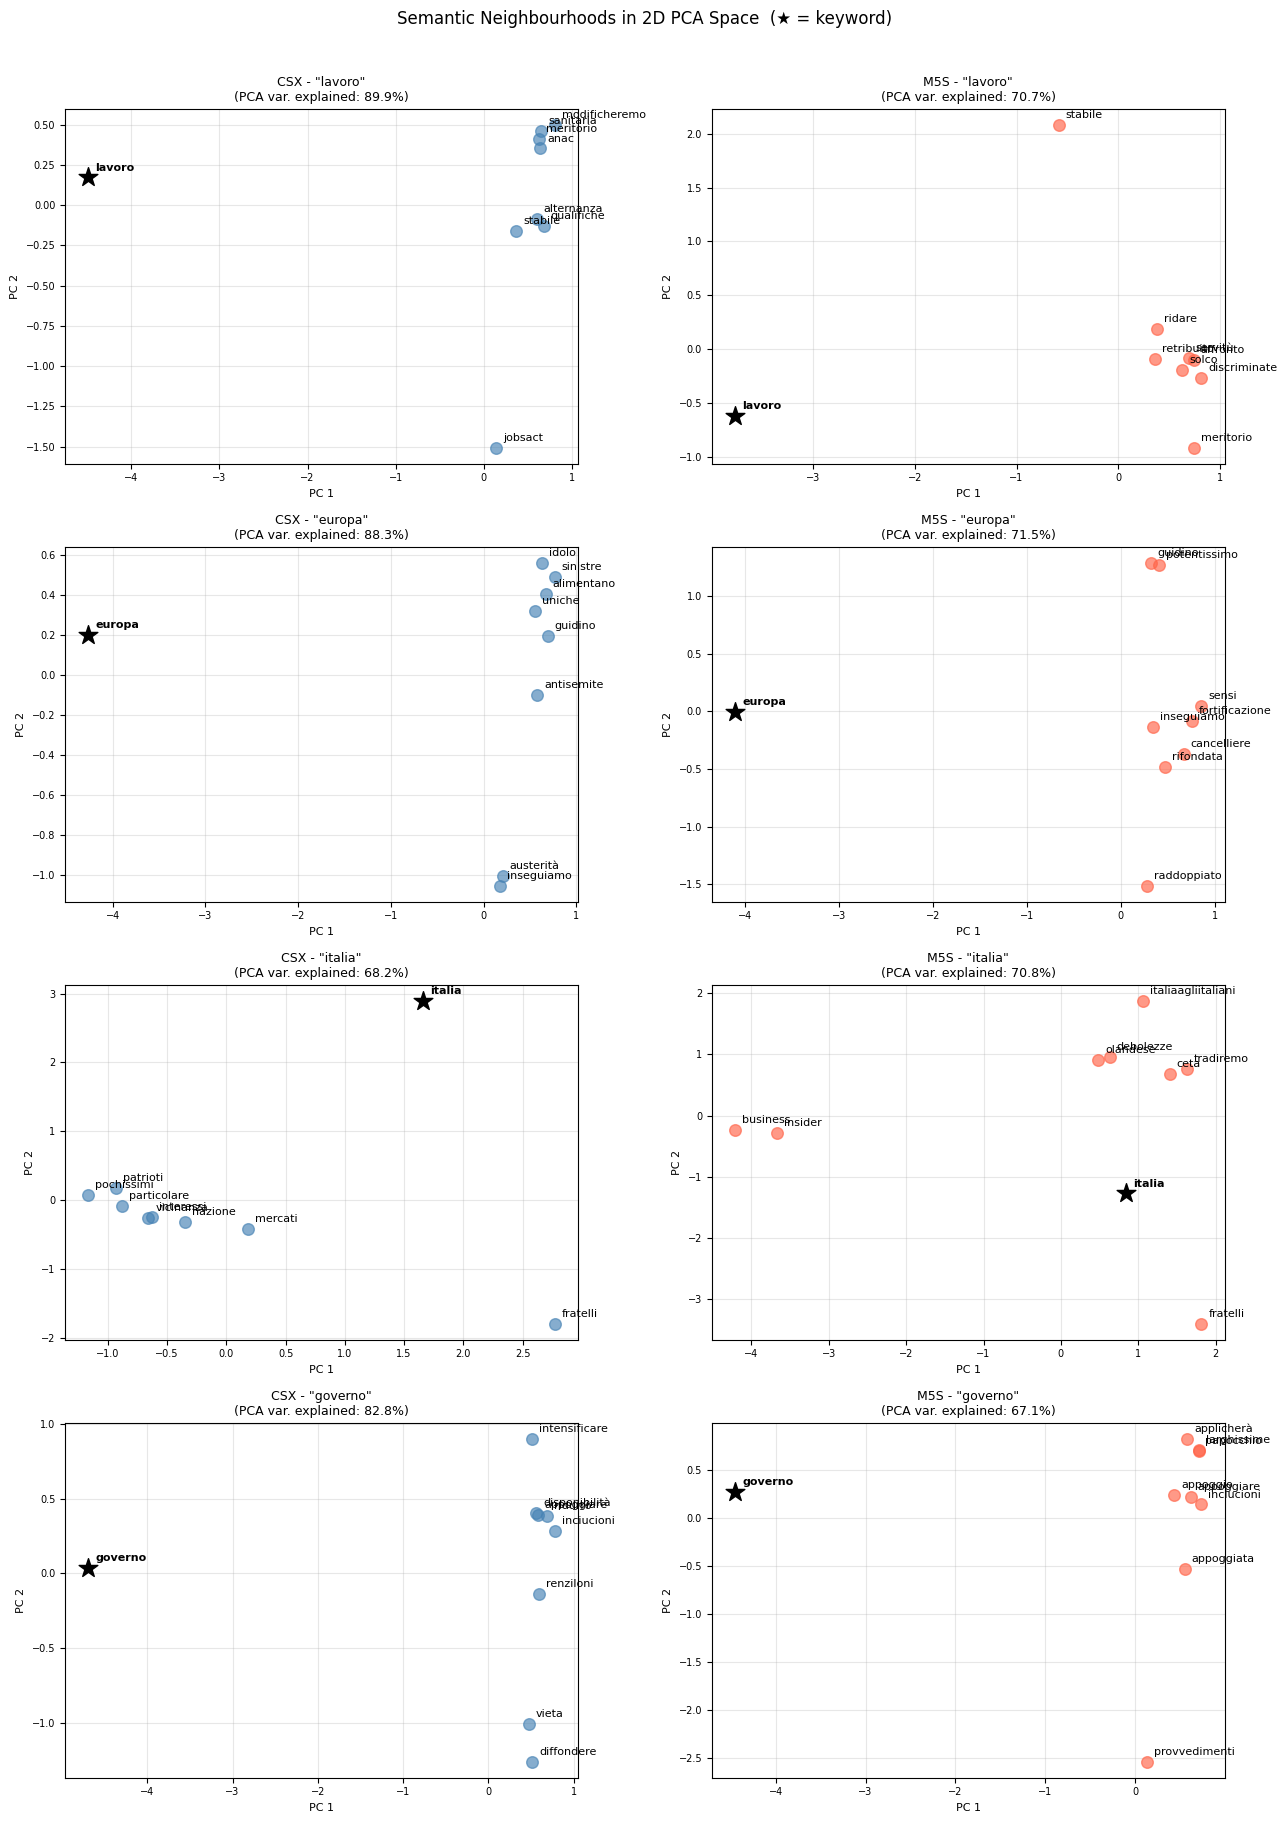

In [19]:
def plot_neighborhood(model, keyword, topn=8, ax=None, color='steelblue', title=''):
    """Project keyword + nearest neighbours to 2D via PCA and scatter-plot."""
    neighbors = [keyword] + [w for w, _ in model.wv.most_similar(keyword, topn=topn)]
    vectors = np.array([model.wv[w] for w in neighbors])

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    coords = pca.fit_transform(vectors)
    var_exp = pca.explained_variance_ratio_.sum()

    ax.scatter(coords[1:, 0], coords[1:, 1], c=color, alpha=0.65, s=70, zorder=3)
    ax.scatter(coords[0, 0], coords[0, 1], c='black', s=200, marker='*', zorder=5)

    for i, word in enumerate(neighbors):
        weight = 'bold' if i == 0 else 'normal'
        ax.annotate(
            word, (coords[i, 0], coords[i, 1]),
            fontsize=8, fontweight=weight,
            xytext=(5, 5), textcoords='offset points'
        )

    ax.set_title(f'{title}\n(PCA var. explained: {var_exp:.1%})', fontsize=9)
    ax.set_xlabel('PC 1', fontsize=8)
    ax.set_ylabel('PC 2', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)


VIZ_KEYWORDS = KEYWORDS[:4]  # visualise up to 4 keywords

fig, axes = plt.subplots(len(VIZ_KEYWORDS), 2,
                          figsize=(13, 4.5 * len(VIZ_KEYWORDS)))

# Ensure axes is always 2D even with a single keyword
if len(VIZ_KEYWORDS) == 1:
    axes = axes[np.newaxis, :]

for row, kw in enumerate(VIZ_KEYWORDS):
    plot_neighborhood(model_csx, kw, topn=8, ax=axes[row, 0],
                      color='steelblue', title=f'CSX - "{kw}"')
    plot_neighborhood(model_m5s, kw, topn=8, ax=axes[row, 1],
                      color='tomato',   title=f'M5S - "{kw}"')

plt.suptitle('Semantic Neighbourhoods in 2D PCA Space  (★ = keyword)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Conclusions

| Aspect | CSX (Centro-Sinistra) | M5S (Movimento 5 Stelle) |
|--------|-----------------------|--------------------------|
| Corpus size | smaller | ~4× larger |
| Model vocabulary | smaller | larger |
| Dominant themes (top tokens) | institutions, rights, labour | inequality, transparency, income |
| Framing of *lavoro* | rights, contracts, unions | income, poverty, exploitation |
| Framing of *europa* | solidarity, integration | fiscal paradise, regulation |
| Framing of *governo* | parliament, coalition | corruption, citizens, distrust |

**Key takeaways:**

- **Word2Vec captures political framing**: the Skip-Gram model is trained to predict context words from a target word; the resulting embeddings therefore encode the *typical distributional context* of each token. Because the two corpora reflect different ideological positions, the same word surfaces different nearest neighbours in each model, this is the distributional signature of framing.

- **CSX framing leans toward rights and social institutions**: labour-related keywords tend to cluster with terms from the legal and union sphere (*contratto*, *sindacato*, *diritti*), reflecting a Centre-Left focus on worker protections and institutional frameworks.

- **M5S framing leans toward inequality and anti-establishment rhetoric**: economic keywords cluster more often with *reddito* (income), *povertà* (poverty), and *corruzione* (corruption), consistent with the Five-Star Movement's populist positioning and anti-elite narrative.

- **Frequency-based keyword extraction is a transparent baseline**: selecting words present and frequent in *both* vocabularies guarantees that the comparison is symmetric and not skewed by party-specific jargon. More sophisticated alternatives, TF-IDF weighting, pointwise mutual information, or cross-corpus analogies — could refine the selection at the cost of interpretability.

- **PCA projections reveal neighbourhood geometry, not absolute positions**: since the two models were trained independently, their embedding spaces are not aligned; only the *relative* distances within each plot carry meaning. Tighter clusters around a keyword indicate a more focused and consistent usage pattern; looser clusters suggest the term is used in more diverse contexts.

- **Corpus size matters**: the M5S corpus is approximately four times larger than the CSX corpus, which generally leads to more stable embeddings with lower variance. For a fairer comparison, sub-sampling the M5S corpus to match the CSX size, or using a corpus-size-normalised evaluation, would be a natural next step.